# Bank Marketing Campaign — Funnel & Conversion Analysis

### Objective
Analyze bank marketing campaign data to understand customer subscription behavior, identify conversion patterns, and generate actionable business insights.

### Tools
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Dataset
Bank Marketing Campaign Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("bank_marketing.csv")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df.shape

(45211, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [6]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [7]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [10]:
df["y"].value_counts(normalize=True).mul(100)

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

In [11]:
df_clean = df.copy()

In [12]:
df_clean["previously_contacted"] = np.where(
    df_clean["pdays"] == -1,
    "No",
    "Yes"
)

In [13]:
df_clean["subscribed"] = df_clean["y"].map({
    "yes": 1,
    "no": 0
})

In [14]:
bins = [17, 25, 35, 45, 55, 65, 100]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]

df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=bins,
    labels=labels
)

In [15]:
df_clean["campaign_group"] = pd.cut(
    df_clean["campaign"],
    bins=[0, 1, 2, 3, 5, 10, float("inf")],
    labels=[
        "1 Contact",
        "2 Contacts",
        "3 Contacts",
        "4-5 Contacts",
        "6-10 Contacts",
        "10+ Contacts"
    ]
)

In [16]:
df_clean["duration_group"] = pd.cut(
    df_clean["duration"],
    bins=[-1, 60, 120, 180, 300, 600, float("inf")],
    labels=[
        "0-1 min",
        "1-2 min",
        "2-3 min",
        "3-5 min",
        "5-10 min",
        "10+ min"
    ]
)

In [17]:
total_customers = len(df_clean)

total_subscriptions = df_clean["subscribed"].sum()

conversion_rate = (
    total_subscriptions / total_customers
) * 100

non_subscribers = (
    total_customers - total_subscriptions
)

print("Total Customers:", total_customers)
print("Total Subscriptions:", total_subscriptions)
print("Conversion Rate:", round(conversion_rate, 2), "%")
print("Non-Subscribers:", non_subscribers)

Total Customers: 45211
Total Subscriptions: 5289
Conversion Rate: 11.7 %
Non-Subscribers: 39922


In [18]:
previous_contact_conversion = (
    df_clean.groupby("previously_contacted")["subscribed"]
    .agg(["count", "sum", "mean"])
)

previous_contact_conversion["conversion_rate"] = (
    previous_contact_conversion["mean"] * 100
)

previous_contact_conversion

,count,sum,mean,conversion_rate
previously_contacted,,,,
No,36954,3384,0.091573,9.157331
Yes,8257,1905,0.230713,23.071333


In [19]:
contact_summary = (
    df_clean.groupby("contact")
    .agg(
        customers=("subscribed", "count"),
        subscriptions=("subscribed", "sum"),
        conversion_rate=("subscribed", "mean")
    )
)

contact_summary["conversion_rate"] *= 100

contact_summary

,customers,subscriptions,conversion_rate
contact,,,
cellular,29285,4369,14.918900
telephone,2906,390,13.420509
unknown,13020,530,4.070661


In [20]:
job_conversion = (
    df_clean.groupby("job")["subscribed"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

job_conversion

job
student          28.678038
retired          22.791519
unemployed       15.502686
management       13.755551
admin.           12.202669
self-employed    11.842939
unknown          11.805556
technician       11.056996
services          8.883004
housemaid         8.790323
entrepreneur      8.271688
blue-collar       7.274969
Name: subscribed, dtype: float64

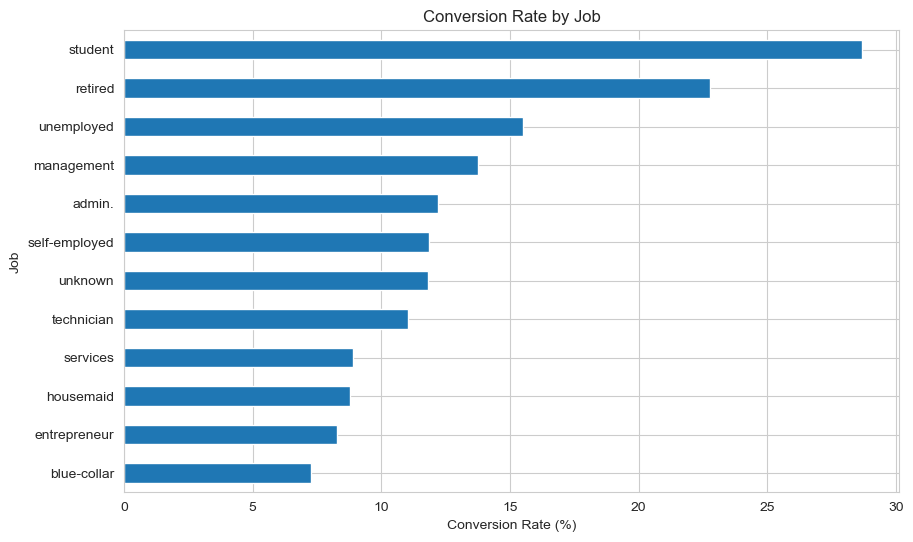

In [21]:
plt.figure(figsize=(10, 6))

job_conversion.sort_values().plot(
    kind="barh"
)

plt.title("Conversion Rate by Job")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Job")

plt.show()

In [22]:
campaign_conversion = (
    df_clean.groupby("campaign_group", observed=False)["subscribed"]
    .agg(["count", "sum", "mean"])
)

campaign_conversion["conversion_rate"] = (
    campaign_conversion["mean"] * 100
)

campaign_conversion

,count,sum,mean,conversion_rate
campaign_group,,,,
1 Contact,17544,2561,0.145976,14.597583
2 Contacts,12505,1401,0.112035,11.203519
3 Contacts,5521,618,0.111936,11.193624
4-5 Contacts,5286,456,0.086266,8.626561
6-10 Contacts,3159,206,0.065211,6.521051
10+ Contacts,1196,47,0.039298,3.929766


In [23]:
previous_contact_conversion

,count,sum,mean,conversion_rate
previously_contacted,,,,
No,36954,3384,0.091573,9.157331
Yes,8257,1905,0.230713,23.071333


In [24]:
monthly_conversion = (
    df_clean.groupby("month")["subscribed"]
    .agg(["count", "sum", "mean"])
)

monthly_conversion["conversion_rate"] = (
    monthly_conversion["mean"] * 100
)

monthly_conversion

,count,sum,mean,conversion_rate
month,,,,
apr,2932,577,0.196794,19.679400
aug,6247,688,0.110133,11.013286
dec,214,100,0.467290,46.728972
feb,2649,441,0.166478,16.647792
jan,1403,142,0.101212,10.121169
jul,6895,627,0.090935,9.093546
jun,5341,546,0.102228,10.222805
mar,477,248,0.519916,51.991614
may,13766,925,0.067195,6.719454


In [25]:
month_order = [
    "jan", "feb", "mar", "apr",
    "may", "jun", "jul", "aug",
    "sep", "oct", "nov", "dec"
]

monthly_conversion = monthly_conversion.reindex(month_order)

monthly_conversion

,count,sum,mean,conversion_rate
month,,,,
jan,1403,142,0.101212,10.121169
feb,2649,441,0.166478,16.647792
mar,477,248,0.519916,51.991614
apr,2932,577,0.196794,19.679400
may,13766,925,0.067195,6.719454
jun,5341,546,0.102228,10.222805
jul,6895,627,0.090935,9.093546
aug,6247,688,0.110133,11.013286
sep,579,269,0.464594,46.459413


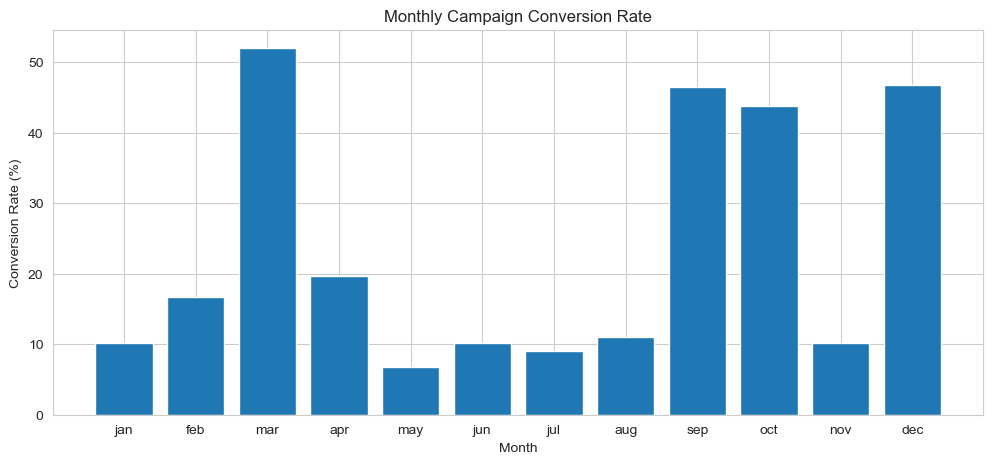

In [26]:
plt.figure(figsize=(12, 5))

plt.bar(
    monthly_conversion.index,
    monthly_conversion["conversion_rate"]
)

plt.title("Monthly Campaign Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")

plt.show()

In [27]:
duration_conversion = (
    df_clean.groupby("duration_group", observed=False)["subscribed"]
    .agg(["count", "sum", "mean"])
)

duration_conversion["conversion_rate"] = (
    duration_conversion["mean"] * 100
)

duration_conversion

,count,sum,mean,conversion_rate
duration_group,,,,
0-1 min,4766,9,0.001888,0.188838
1-2 min,9278,202,0.021772,2.177193
2-3 min,8616,498,0.057799,5.779944
3-5 min,10277,1122,0.109176,10.917583
5-10 min,8484,1625,0.191537,19.153701
10+ min,3790,1833,0.483641,48.364116


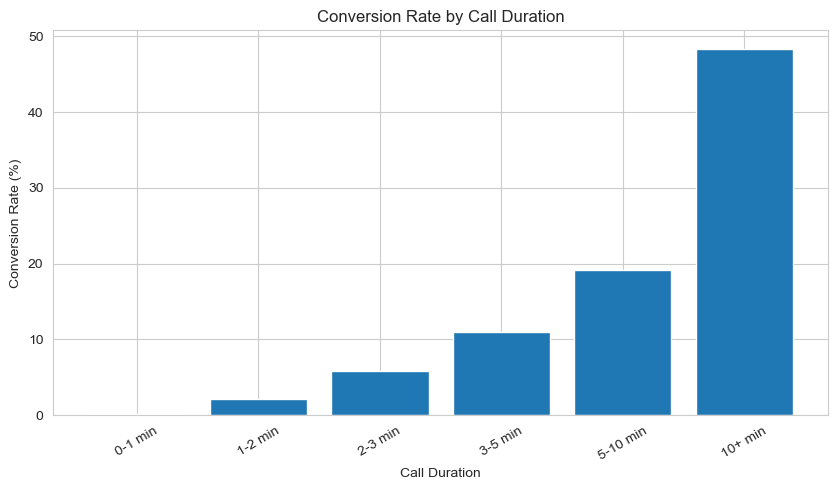

In [28]:
plt.figure(figsize=(10, 5))

plt.bar(
    duration_conversion.index.astype(str),
    duration_conversion["conversion_rate"]
)

plt.title("Conversion Rate by Call Duration")
plt.xlabel("Call Duration")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=30)

plt.show()

In [29]:
housing_conversion = (
    df_clean.groupby("housing")["subscribed"]
    .mean()
    .mul(100)
)

housing_conversion

housing
no     16.702355
yes     7.699960
Name: subscribed, dtype: float64

In [30]:
loan_conversion = (
    df_clean.groupby("loan")["subscribed"]
    .mean()
    .mul(100)
)

loan_conversion

loan
no     12.655727
yes     6.681391
Name: subscribed, dtype: float64

In [31]:
df_clean.to_csv(
    "bank_marketing_cleaned.csv",
    index=False
)

## Key Business Insights
1. Overall subscription conversion was 11.70%, with 5,289 subscriptions from 45,211 customers.

2. Customers with previous campaign contact converted at 23.07%, compared with 9.16% for customers without previous contact history.

3. Observed conversion declined as campaign contact frequency increased, from 14.60% for one contact to 3.93% for 10+ contacts.

4. Conversion varied substantially across occupational segments, with students and retired customers showing the highest observed conversion rates.

5. Monthly campaign conversion varied considerably, although high-conversion months generally had smaller customer volumes.

6. Call duration was strongly associated with conversion, increasing from 0.19% for calls under one minute to 48.36% for calls exceeding ten minutes.

7. Customers without housing or personal loans showed higher observed conversion rates than customers with these loans.

## Business Recommendations
1. Use previous campaign engagement as a segmentation variable when designing follow-up campaigns.

2. Monitor conversion by campaign contact frequency and test different follow-up strategies.

3. Develop and test customer-segment-specific messaging using attributes such as occupation, age group, loan status, and previous engagement.

4. Investigate monthly campaign performance alongside campaign volume and customer composition before changing campaign timing.

5. Analyze successful customer conversations to identify communication patterns that can improve sales training and campaign effectiveness.

6. Validate proposed campaign changes through controlled experiments before treating observed relationships as causal business rules.

## Conclusion

This analysis examined 45,211 customer records from a bank marketing campaign to understand subscription conversion and campaign performance.

The campaign generated 5,289 subscriptions, resulting in an overall observed conversion rate of 11.70%. Conversion varied substantially across previous campaign engagement, customer segments, contact methods, campaign contact frequency, campaign months, loan profiles, and call duration.

Previous campaign engagement was associated with a higher observed conversion rate, while customers receiving a greater number of campaign contacts showed lower observed conversion rates. Customer segments also displayed meaningful differences in conversion performance. Call duration showed a strong association with subscription, although it should be treated as an interaction-stage variable rather than a pre-contact targeting variable.

The findings suggest opportunities to improve campaign effectiveness through customer segmentation, better use of campaign history, evaluation of contact-frequency strategies, investigation of campaign timing, and analysis of successful customer interactions.

These findings represent relationships observed in historical data and should be validated through controlled experiments before being converted into fixed campaign rules.
